# Calculate Expected Events
Determine the likelihood of observing AGN microlensing events

## Generic Imports

In [8]:
import numpy as np
from scipy.integrate import quad
from astropy.constants import G, c, M_sun

## Constants

In [9]:
from astropy.cosmology import Planck18
import astropy.units as u

# 1. Physical Constants and Parameters
rho_s = 4.88e6 * u.M_sun / u.kpc**3
R_sun = 8.0 * u.kpc
R_vir = 200.0 * u.kpc  # Limit of the MW halo integration
r_s = R_vir # Assume our lens is located at the virial radius of the MW halo to force us to integrate across the entire halo when calculating optical depth

# 2. Setup AGN Source Distance
z_agn = 5.0
d_a_kpc = Planck18.angular_diameter_distance(z_agn).to(u.kpc).value
D_s = d_a_kpc 


# Stripe-82 galactic coordinates
l = np.radians(96)
b = np.radians(-60)

## Calculate Optical Depth

In [10]:
# 1. Define inputs as pure floats (using consistent units: kpc, M_sun, km, s)
# Convert all parameters to simple values first
rho_s_val = rho_s.to(u.M_sun / u.kpc**3).value
r_s_val = r_s.to(u.kpc).value
R_sun_val = R_sun.to(u.kpc).value
R_vir_val = R_vir.to(u.kpc).value
D_s_val = D_s

# 2. Define functions using pure numerical operations
def rho_nfw_num(r):
    return rho_s_val / ((r / r_s_val + 1e-9) * (1 + r / r_s_val)**2)

def dist_from_center_num(d_l):
    x = R_sun_val - d_l * np.cos(b) * np.cos(l)
    y = d_l * np.cos(b) * np.sin(l)
    z = d_l * np.sin(b)
    return np.sqrt(x**2 + y**2 + z**2)

def integrand_num(d_l):
    r = dist_from_center_num(d_l)
    # The weight (d_l * (D_s - d_l) / D_s) results in units of kpc
    # Result of this function will be (M_sun / kpc^3) * kpc = M_sun / kpc^2
    return rho_nfw_num(r) * d_l * (D_s_val - d_l) / D_s_val

# 3. Perform integration
# The result of the integral has units of M_sun / kpc^2
integral_result, error = quad(integrand_num, 0, R_vir_val)

# 4. Apply physical constants
# G in (kpc * km^2) / (s^2 * M_sun)
# c in km/s
G_kpc = G.to(u.kpc * u.km**2 / (u.s**2 * u.M_sun)).value
c_kpc = c.to(u.km / u.s).value

# tau = (4 * pi * G / c^2) * integral
# Units check: (kpc / M_sun) * (M_sun / kpc^2) * (some distance factor to cancel)
# Since the integral was over dl (kpc), we multiply by a conversion to keep it dimensionless
tau = (4 * np.pi * G_kpc / c_kpc**2) * integral_result

print(f"Optical Depth (tau): {tau:.4e}")

Optical Depth (tau): 5.3601e-05


## Calculate Einstein Radius

In [11]:
import numpy as np
from astropy.cosmology import Planck18
import astropy.units as u

# Lens properties
m_lens = 10**4 * M_sun
d_l_kpc = 20 * u.kpc
# Convert to meters explicitly
d_l_m = d_l_kpc.to(u.m).value

# Source properties (z=2)
d_s_m = Planck18.angular_diameter_distance(2.0).to(u.m).value
d_ls_m = d_s_m - d_l_m

# Define function to work with pure floats
def einstein_rad_meters(m_val, d_l_val, d_s_val):
    d_ls_val = d_s_val - d_l_val
    G_val = G.to(u.m**3 / (u.kg * u.s**2)).value
    c_val = c.to(u.m / u.s).value
    
    # Calculate R_E directly in meters: sqrt(4*G*M/c^2 * D_LS*D_L/D_S)
    R_E_sq = (4 * G_val * m_val.to(u.kg).value / c_val**2) * (d_ls_val * d_l_val / d_s_val)
    return np.sqrt(R_E_sq)

# 1. Physical Einstein Radius
R_E_m = einstein_rad_meters(m_lens, d_l_m, d_s_m)
# 2. Angular Einstein Radius (radians)
theta_E = R_E_m / d_l_m

print(f"Einstein radius (radians): {theta_E:.3e}")
print(f"Physical Einstein radius (meters): {R_E_m:.3e}")

Einstein radius (radians): 3.094e-07
Physical Einstein radius (meters): 1.909e+14


## Calculate Crossing Time

In [12]:
# Setup velocity
sigma = 155 * u.km / u.s
v_eff = (sigma * np.sqrt(np.pi / 2)).to(u.m / u.s).value

def calculate_crossing_time_yr(r_e_m, v_eff_ms):
    """
    Calculates Einstein crossing time in years.
    r_e_m: Physical Einstein radius in meters (float)
    v_eff_ms: Effective transverse velocity in m/s (float)
    """
    t_E_s = r_e_m / v_eff_ms
    # Convert seconds to years
    t_E_yr = t_E_s / (365.25 * 24 * 3600)
    return t_E_yr

# Execute with pure floats
t_e_yr = calculate_crossing_time_yr(R_E_m, v_eff)

print(f"Einstein crossing time (years): {t_e_yr:.2f}")

Einstein crossing time (years): 31.14


## Calculate Event Rate 

In [13]:
# Updated differential event rate function using consistent SI units
def differential_event_rate(d_l_kpc, D_s_kpc, v_eff_ms, m_lens_kg):
    # Convert distances to meters for the calculation
    d_l_m = d_l_kpc * 3.086e+19 
    d_s_m = D_s_kpc * 3.086e+19
    
    # R_E calculation in meters
    G_si = 6.674e-11
    c_si = 299792458
    d_ls_m = d_s_m - d_l_m
    R_E_sq = (4 * G_si * m_lens_kg / c_si**2) * (d_ls_m * d_l_m / d_s_m)
    r_e_m = np.sqrt(R_E_sq)
    
    # Crossing time in years
    t_E_s = r_e_m / v_eff_ms
    t_E_yr = t_E_s / (365.25 * 24 * 3600)
    
    # Optical depth (tau) contribution
    # Ensure all inputs to rho_nfw_num are in kpc
    rho = rho_nfw_num(dist_from_center_num(d_l_kpc)) # M_sun / kpc^3
    # Convert rho to kg/m^3 for SI consistency
    rho_si = rho * (1.989e30 / (3.086e19)**3) 
    
    # Differential tau (using SI)
    # The geometric part must also be in meters
    d_tau = (4 * np.pi * G_si / c_si**2) * (rho_si * d_l_m * d_ls_m / d_s_m)
    
    # Return dGamma/dd_l (convert d_l_m to d_l_kpc if integrating over kpc)
    return (2 / (np.pi * t_E_yr)) * d_tau * 3.086e19 

# When calling quad, ensure you are integrating over kpc
total_gamma, error = quad(differential_event_rate, 0, R_vir_val, args=(D_s_val, v_eff, m_lens.to(u.kg).value))

print(f"Total Microlensing event rate (events/star/year): {total_gamma:e}")
print(f"Total Microlensing events over 20 years for 20,000 stars: {total_gamma * 20 * 20000}")

Total Microlensing event rate (events/star/year): 7.100580e-07
Total Microlensing events over 20 years for 20,000 stars: 0.2840231911985414


<>:22: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:22: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/tmp/ipykernel_229957/1058121777.py:22: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('Black Hole Mass ($M_{\odot}$)')


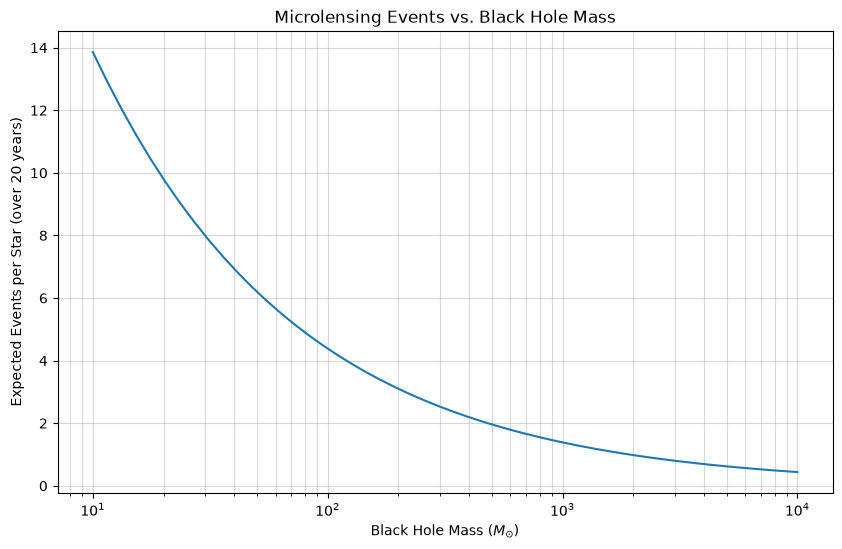

In [14]:
import matplotlib.pyplot as plt

masses = np.logspace(1, 4, 50) # 10^1 to 10^4 M_sun

# Calculate events for each mass
events_over_20_years = []
for m in masses:
    # Get R_E and t_E as pure floats
    r_e_val = einstein_rad_meters(m * M_sun, d_l_m, d_s_m)
    t_e_val = calculate_crossing_time_yr(r_e_val, v_eff)
    
    # Calculate gamma using the global tau
    gamma = (2 * tau) / (np.pi * t_e_val)
    events = gamma * 20 * 20000 
    events_over_20_years.append(events)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(masses, events_over_20_years)
plt.xscale('log')
plt.yscale('linear')
plt.xlabel('Black Hole Mass ($M_{\odot}$)') 
plt.ylabel('Expected Events per Star (over 20 years)')
plt.title('Microlensing Events vs. Black Hole Mass')
plt.grid(True, which="both", ls="-", alpha=0.5)